# Numerai Data Exploration

Initial exploration of the Numerai v5.3 training dataset.

Goals:
- Inspect the dataset without loading the full file into memory
- Understand dataset size and structure
- Examine the schema and available columns

## 1. Load Parquet Metadata

Open the Parquet file with PyArrow without loading the full dataset into memory.

In [2]:
from pathlib import Path
import pyarrow.parquet as pq

DATA_PATH = Path("../data/train.parquet")

parquet_file = pq.ParquetFile(DATA_PATH)

## 2. Dataset Size

Inspect the number of rows, columns, and Parquet row groups.

In [3]:

print("Number of rows:", parquet_file.metadata.num_rows)
print("Number of columns:", parquet_file.metadata.num_columns)
print("Number of row groups:", parquet_file.metadata.num_row_groups)

Number of rows: 2746268
Number of columns: 3599
Number of row groups: 3


## 3. Dataset Schema

Inspect column names and data types stored in the Parquet file.

In [4]:
print(parquet_file.schema)

required group field_id=-1 schema {
  optional binary field_id=-1 era (String);
  optional binary field_id=-1 data_type (String);
  optional int32 field_id=-1 feature_shaded_hallucinatory_dactylology (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 feature_itinerant_hexahedral_photoengraver (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 feature_prudent_pileate_oven (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 feature_subalpine_apothegmatical_ajax (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 feature_pistachio_atypical_malison (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 feature_symmetrical_spongy_tricentenary (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 feature_ungrounded_transpontine_winder (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 feature_aseptic_eely_hemiplegia (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 feature_elemental_easier_alkalinity (Int

## 4. Column Structure

Inspect the column names and classify them into identifiers, features, and targets without loading the full dataset.

In [5]:
columns = parquet_file.schema.names

feature_cols = [col for col in columns if col.startswith("feature_")]
target_cols = [col for col in columns if col.startswith("target_")]
other_cols = [
    col for col in columns
    if not col.startswith("feature_") and not col.startswith("target_")
]

print("Total columns:", len(columns))
print("Feature columns:", len(feature_cols))
print("Target columns:", len(target_cols))
print("Other columns:", other_cols)

Total columns: 3599
Feature columns: 3555
Target columns: 40
Other columns: ['era', 'data_type', 'target', 'id']


In [6]:
for col in target_cols:
    print(col)

target_agnes_20
target_agnes_60
target_alpha_20
target_alpha_60
target_bravo_20
target_bravo_60
target_caroline_20
target_caroline_60
target_charlie_20
target_charlie_60
target_claudia_20
target_claudia_60
target_cyrusd_20
target_cyrusd_60
target_delta_20
target_delta_60
target_echo_20
target_echo_60
target_ender_20
target_ender_60
target_jasper_20
target_jasper_60
target_jeremy_20
target_jeremy_60
target_ralph_20
target_ralph_60
target_rowan_20
target_rowan_60
target_sam_20
target_sam_60
target_teager2b_20
target_teager2b_60
target_tyler_20
target_tyler_60
target_victor_20
target_victor_60
target_waldo_20
target_waldo_60
target_xerxes_20
target_xerxes_60


## 5. Feature Metadata

Inspect `features.json` to understand how Numerai organizes the available features into different feature sets.

In [7]:
import json

FEATURES_PATH = Path("../data/features.json")

with open(FEATURES_PATH, "r") as f:
    feature_metadata = json.load(f)

print(feature_metadata.keys())

dict_keys(['feature_sets', 'targets'])


In [8]:
feature_sets = feature_metadata["feature_sets"]

print(feature_sets.keys())

dict_keys(['small', 'medium', 'all', 'v2_equivalent_features', 'v3_equivalent_features', 'fncv3_features', 'intelligence', 'charisma', 'strength', 'dexterity', 'constitution', 'wisdom', 'agility', 'serenity', 'sunshine', 'rain', 'midnight', 'faith', 'quantum'])


In [9]:
for set_name, features in feature_sets.items():
    print(set_name, ":", len(features))

small : 42
medium : 780
all : 3555
v2_equivalent_features : 304
v3_equivalent_features : 1000
fncv3_features : 400
intelligence : 35
charisma : 290
strength : 135
dexterity : 51
constitution : 335
wisdom : 140
agility : 145
serenity : 95
sunshine : 325
rain : 666
midnight : 244
faith : 372
quantum : 807


## 6. Load a Small Feature Set

Load identifiers, the default target, and the 42-feature `small` set for initial exploration without loading all 3,555 features into memory.

In [10]:
import pandas as pd

small_features = feature_sets["small"]

selected_cols = [
    "era",
    "data_type",
    "id",
    "target",
] + small_features

train_small = pd.read_parquet(
    DATA_PATH,
    columns=selected_cols
)

In [11]:
train_small.shape

(2746268, 45)

In [12]:
train_small.head()

,era,data_type,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,train,0.25,2,2,2,2,2,0,1,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,train,0.50,2,2,2,2,2,1,4,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,train,1.00,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,train,0.00,2,2,2,2,2,1,4,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,train,0.50,2,2,2,2,2,0,0,...,1,0,1,0,0,2,2,1,4,2


In [13]:
memory_mb = train_small.memory_usage(deep=True).sum() / 1024**2
print(f"Memory usage: {memory_mb:.2f} MB")

Memory usage: 248.81 MB


In [14]:
print("Index name:", train_small.index.name)
print("Index type:", train_small.index.dtype)
print("Columns:", train_small.columns[:5].tolist())

Index name: id
Index type: str
Columns: ['era', 'data_type', 'target', 'feature_antistrophic_striate_conscriptionist', 'feature_bicameral_showery_wallaba']


**Observation:** `id` is restored by pandas as the DataFrame index from the Parquet metadata, so it is not included in the 45 data columns.

In [15]:
print("Number of eras:", train_small["era"].nunique())

print("First eras:")
print(train_small["era"].unique()[:10])

print("Last eras:")
print(train_small["era"].unique()[-10:])
era_counts = train_small.groupby("era").size()

era_counts.describe()

Number of eras: 574
First eras:
<ArrowStringArray>
['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009',
 '0010']
Length: 10, dtype: str
Last eras:
<ArrowStringArray>
['0565', '0566', '0567', '0568', '0569', '0570', '0571', '0572', '0573',
 '0574']
Length: 10, dtype: str


count     574.000000
mean     4784.439024
std       752.691030
min      2314.000000
25%      4437.500000
50%      4923.000000
75%      5298.500000
max      6009.000000
dtype: float64

**Observation:** Examine how the cross-sectional universe size changes across eras.

<Axes: title={'center': 'Number of Observations per Era'}, xlabel='era'>

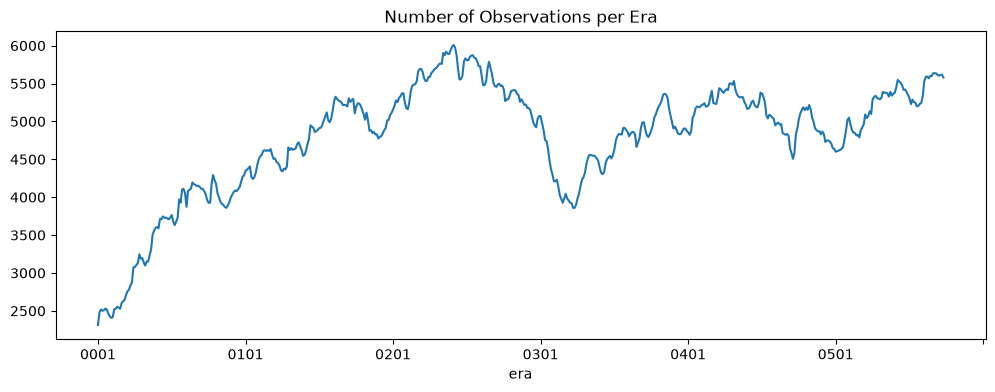

In [16]:
era_counts.plot(
    figsize=(12, 4),
    title="Number of Observations per Era"
)

## 8. Data Type

Inspect the `data_type` column to understand how observations are labeled in the training dataset.

In [17]:
train_small["data_type"].value_counts()

data_type
train    2746268
Name: count, dtype: int64[pyarrow]

**Observation:** All 2,746,268 observations in `train.parquet` have `data_type = "train"`, so this column provides no additional variation within the training dataset.

## 9. Target Distribution

Examine the distribution of the default target (`target_ender_60`) used as the prediction label.

In [18]:
train_small["target"].describe()

count    2.746268e+06
mean     4.999478e-01
std      2.236927e-01
min      0.000000e+00
25%      5.000000e-01
50%      5.000000e-01
75%      5.000000e-01
max      1.000000e+00
Name: target, dtype: float64

In [19]:
train_small["target"].value_counts().sort_index()

target
0.00     137882
0.25     548684
0.50    1373136
0.75     549258
1.00     137308
Name: count, dtype: int64

**Observation:** The default target is discretized into five values: 0, 0.25, 0.5, 0.75, and 1.0. The distribution is approximately symmetric (5%, 20%, 50%, 20%, 5%) around 0.5. The target therefore represents an ordinal/ranked future outcome rather than a raw future return.

In [21]:
target_by_era = (
    train_small
    .groupby("era")["target"]
    .value_counts(normalize=True)
    .unstack()
)

target_by_era.head()

target,0.00,0.25,0.50,0.75,1.00
era,,,,,
0001,0.050562,0.199222,0.500432,0.199654,0.050130
0002,0.050363,0.199436,0.500403,0.199839,0.049960
0003,0.050437,0.199762,0.499603,0.200159,0.050040
0004,0.050400,0.199600,0.500000,0.200000,0.050000
0005,0.050577,0.199522,0.499801,0.199920,0.050179


In [22]:
target_by_era.describe()

target,0.00,0.25,0.50,0.75,1.00
count,574.000000,574.000000,574.000000,574.000000,574.000000
mean,0.050214,0.199786,0.500000,0.200002,0.049998
std,0.000079,0.000095,0.000135,0.000085,0.000066
min,0.050085,0.199222,0.499603,0.199654,0.049815
25%,0.050152,0.199737,0.499901,0.199954,0.049939
50%,0.050208,0.199792,0.500000,0.200000,0.050000
75%,0.050265,0.199851,0.500098,0.200062,0.050056
max,0.050577,0.199966,0.500432,0.200302,0.050179


**Observation:** The target distribution is highly stable across eras, with approximately 5%, 20%, 50%, 20%, and 5% of observations assigned to target values 0, 0.25, 0.5, 0.75, and 1.0, respectively. This confirms that the target is constructed as an era-level cross-sectional ordinal outcome rather than a raw return.

## 10. Feature Distribution and Missing Values

Examine the value distributions, data types, and missing values of the small feature set.

In [23]:
train_small[small_features].describe()

,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,feature_donnard_groutier_twinkle,feature_elusive_vapoury_accomplice,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
count,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,...,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06,2.746268e+06
mean,1.999918e+00,1.999949e+00,1.999928e+00,1.999924e+00,1.999928e+00,1.999914e+00,1.999913e+00,1.999928e+00,1.999928e+00,1.999915e+00,...,1.999914e+00,1.999913e+00,1.999913e+00,1.999913e+00,1.999915e+00,1.999928e+00,1.999924e+00,1.999915e+00,1.999916e+00,1.999918e+00
std,1.402037e+00,1.096288e+00,1.314663e+00,1.374102e+00,1.320679e+00,1.414359e+00,1.414359e+00,1.320679e+00,1.320679e+00,1.414360e+00,...,1.414359e+00,1.414359e+00,1.414359e+00,1.414359e+00,1.414359e+00,1.320679e+00,1.374102e+00,1.414360e+00,1.414359e+00,1.402037e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,...,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
75%,3.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,...,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00
max,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,...,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00


In [ ]:
missing_counts = train_small[small_features].isna().sum() #series，for each feature，sum of nan

print("Total missing values:", missing_counts.sum())
print("Features with missing values:", (missing_counts > 0).sum())

Total missing values: 0
Features with missing values: 0


In [25]:
example_feature = small_features[0]

print("Feature:", example_feature)
print(train_small[example_feature].value_counts().sort_index())

Feature: feature_antistrophic_striate_conscriptionist
feature_antistrophic_striate_conscriptionist
0    539947
1    539614
2    587258
3    539614
4    539835
Name: count, dtype: int64


In [26]:
feature_mean_by_era = (
    train_small
    .groupby("era")[example_feature]
    .mean()
)

feature_mean_by_era.describe()

count    574.000000
mean       1.999918
std        0.000169
min        1.999295
25%        2.000000
50%        2.000000
75%        2.000000
max        2.000000
Name: feature_antistrophic_striate_conscriptionist, dtype: float64

<Axes: title={'center': 'Mean Feature Value by Era'}, xlabel='era'>

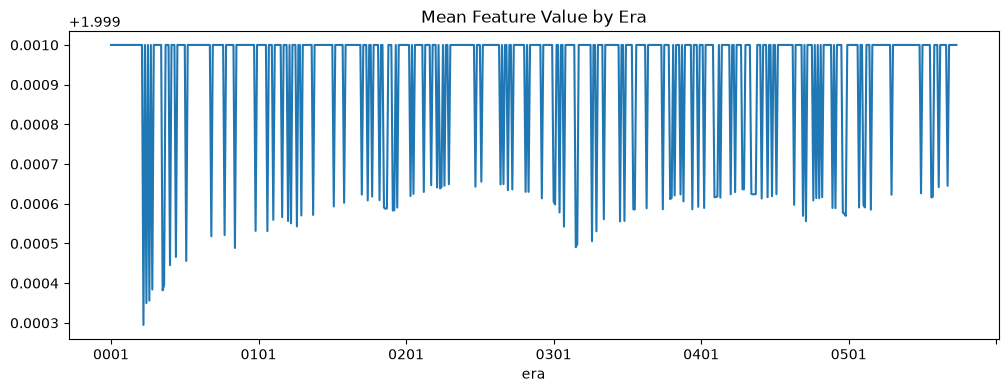

In [27]:
feature_mean_by_era.plot(
    figsize=(12, 4),
    title="Mean Feature Value by Era"
)

**Observation:** The example feature has an extremely stable cross-sectional mean of approximately 2.0 across all 574 eras, suggesting strong era-level normalization. This mean-based check does not by itself guarantee that the full feature distribution is stable.

## 11. Feature-Target Relationship

Examine the simple correlation between the small feature set and the target as an initial measure of predictive relationship.

In [28]:
feature_target_corr = (
    train_small[small_features]
    .corrwith(train_small["target"])
    .sort_values(ascending=False)
)

feature_target_corr

feature_donnard_groutier_twinkle                 0.009034
feature_simulated_nonclassified_intercessor      0.008656
feature_unmodish_zymogenic_rousing               0.008078
feature_hempen_unionist_cone                     0.007544
feature_willful_sere_chronobiology               0.007309
feature_bicameral_showery_wallaba                0.007255
feature_maledictive_latter_psellism              0.007197
feature_jacobinical_symmetric_roll               0.006362
feature_musicianly_aspirate_creativity           0.005876
feature_trimeter_soggy_greatest                  0.005705
feature_bridal_fingered_pensioner                0.005673
feature_unministerial_unextenuated_teleostean    0.005552
feature_petty_upraised_caddice                   0.005405
feature_geminate_crummiest_scourer               0.005373
feature_dialectal_homely_cambodia                0.005258
feature_stretchy_spiniest_fizgig                 0.005181
feature_pottier_unmanly_collyrium                0.004579
feature_tridac

In [29]:
top_feature = feature_target_corr.abs().idxmax()

print("Top feature:", top_feature)
print("Pooled correlation:", feature_target_corr[top_feature])

Top feature: feature_saddening_unsound_rustling
Pooled correlation: -0.010924812735090281


In [31]:
era_corr = (
    train_small
    .groupby("era")
    .apply(lambda x: x[top_feature].corr(x["target"]))
)
era_corr.describe()

d:\Github Local\numerai-research\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Github Local\numerai-research\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\Github Local\numerai-research\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Github Local\numerai-research\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\Github Local\numerai-research\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Github Local\numerai-research\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divi

count    474.000000
mean      -0.011847
std        0.013868
min       -0.053139
25%       -0.021637
50%       -0.010789
75%       -0.002647
max        0.025326
dtype: float64

In [32]:
feature_nunique_by_era = (
    train_small
    .groupby("era")[top_feature]
    .nunique()
)

feature_nunique_by_era.value_counts().sort_index()

feature_saddening_unsound_rustling
1    100
5    474
Name: count, dtype: int64

**Observation:** The feature with the largest absolute pooled correlation is constant within 100 of the 574 eras. Its era-level correlation is therefore undefined in those eras, leaving 474 valid era correlations. This highlights that overall feature-target correlation alone does not guarantee consistent cross-sectional information across time.

## 12. EDA Summary

### Dataset Structure
- The training dataset contains 2,746,268 observations across 574 eras.
- The Parquet file contains 3,599 fields in total: 3,555 features, 40 target-related columns, and identifier/metadata fields.
- `id` is restored by pandas as the DataFrame index.
- All observations in `train.parquet` have `data_type = "train"`.

### Era Structure
- Eras range from `0001` to `0574`.
- Each era represents a cross-sectional set of anonymous assets.
- The average era contains approximately 4,784 observations, with counts ranging from 2,314 to 6,009.
- Cross-sectional universe size therefore varies across eras.

### Feature Sets
- Numerai provides several predefined feature sets.
- `small` contains 42 features, `medium` contains 780, and `all` contains 3,555.
- Additional named and version-specific feature subsets are available for specialized research.

### Target
- The default `target` is an ordinal, cross-sectionally processed target rather than a raw future return.
- It takes five values: `0`, `0.25`, `0.5`, `0.75`, and `1.0`.
- Within each era, the distribution is extremely stable at approximately 5%, 20%, 50%, 20%, and 5%.
- The default target corresponds to `target_ender_60`.

### Features
- The examined features take discrete values from `0` to `4`.
- The 42-feature `small` set contains no missing values.
- The example feature has a cross-sectional mean very close to `2.0` across all eras, suggesting strong era-level normalization.
- Some features can be constant within particular eras, meaning they provide no cross-sectional ranking information during those periods.

### Feature-Target Relationship
- Individual feature-target correlations are small, generally around the ±0.01 range for the `small` feature set.
- Pooled correlation alone is insufficient for evaluating a feature because Numerai is fundamentally a cross-sectional, era-based prediction problem.
- Era-level correlations provide a more appropriate view of signal consistency through time.